**Classification**                                                       
Méthodes K-means et FCM et visualisation de la classification avec l'ACP

In [ ]:
import pandas
#Stat - librairie numpy
import numpy as np#scikit-learn
import sklearn
#scree plot
import matplotlib.pyplot as plt
X = pandas.read_table ("/content/Fromages (4).txt", sep="      ",header=0, index_col =0)
print(X)
print(X.describe())
#dimension
print(X.shape)
#nombre d'observations
n = X.shape[0]
#nombre de variables
p = X.shape[1]

                    calories  sodium  calcium  lipides  retinol  folates  \
Fromages                                                                   
CarredelEst              314   353.5     72.6     26.3     51.6     30.3   
Babybel                  314   238.0    209.8     25.1     63.7      6.4   
Beaufort                 401   112.0    259.4     33.3     54.9      1.2   
Bleu                     342   336.0    211.1     28.9     37.1     27.5   
Camembert                264   314.0    215.9     19.5    103.0     36.4   
Cantal                   367   256.0    264.0     28.8     48.8      5.7   
Chabichou                344   192.0     87.2     27.9     90.1     36.3   
Chaource                 292   276.0    132.9     25.4    116.4     32.5   
Cheddar                  406   172.0    182.3     32.5     76.4      4.9   
Comte                    399    92.0    220.5     32.4     55.9      1.3   
Coulomniers              308   222.0     79.2     25.6     63.6     21.1   
Edam        

Classification Kmeans et visualisation de la partition finale avec ACP

In [ ]:

#k-means
from sklearn import cluster
kmeans = cluster.KMeans(n_clusters=4)
kmeans.fit(X)

#index triés des groupes
idk = np.argsort(kmeans.labels_)
#affichage des observations et leurs groupes
print(pandas.DataFrame(X.index[idk],kmeans.labels_[idk]))

#distances aux centres de classes des observations
A=kmeans.transform(X)
print(pandas.DataFrame({'Classe':kmeans.labels_,'ID':X.index,'DistG1':A[:,0],'DistG2':A[:,1],'DistG3':A[:,2],'DistG4':A[:,3]}))


             Fromages
0            Beaufort
0                Edam
0               Comte
0             Cheddar
0            Emmental
0            Vacherin
1             Babybel
1         CarredelEst
1         Coulomniers
1            Chaource
1           Chabichou
1           Camembert
1         Fr.fondu.45
1            Pyrenees
1           Maroilles
1                Bleu
1           Reblochon
1                Tome
1          Rocquefort
1             Morbier
1         PontlEveque
2      Fr.frais40nat.
2  Fr.chevrepatemolle
2      Fr.frais20nat.
2  Yaourtlaitent.nat.
2       Petitsuisse40
3              Cantal
3            Parmesan
3         SaintPaulin
    Classe                  ID      DistG1      DistG2      DistG3      DistG4
0        1         CarredelEst  298.502883  114.837808  351.978663  249.964938
1        1             Babybel  139.999648   70.117569  276.459504   85.379115
2        0            Beaufort   38.570041  221.828718  331.731037  141.870105
3        1              

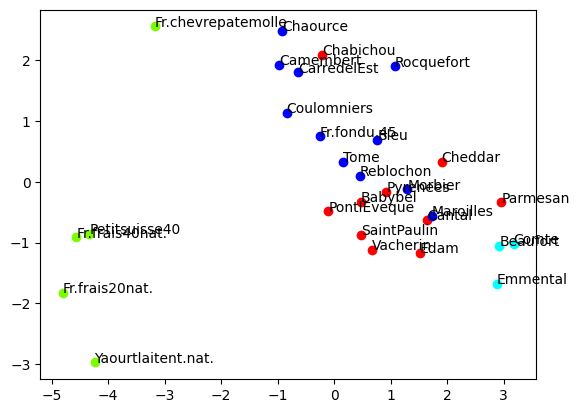

In [ ]:
# VISUALISATION ACP
from sklearn.preprocessing import StandardScaler
#instanciation
sc = StandardScaler()
#transformation – centrage-réduction
Z = sc.fit_transform(X)
from sklearn.decomposition import PCA
acp= PCA(n_components =2).fit_transform(Z)
#projeter dans le plan factoriel
#avec un code couleur différent selon le groupe
#remarquer le rôle de zip() dans la boucle
import matplotlib.pyplot as plt
for couleur,k in zip([ 'red','blue','lawngreen','aqua'],[0,1,2,3]):
    plt.scatter(acp[kmeans.labels_==k,0], acp[kmeans.labels_==k,1],c=couleur)

n = X.shape[0]
#mettre les labels des points
for i in range(n):
    plt.annotate(X.index[i],(acp[i,0], acp[i,1]))
plt.show()


In [ ]:
!pip install -q scikit-fuzzy
import skfuzzy as fuzz
# Attention !!! Entree transposée de X pour FCM
, u, , , jm, p,  = fuzz.cluster.cmeans(X.T, c=4, m=2.0, error=0.001, maxiter=1000)
# u : matrice finale des degres d'appartenance ; jm : Critère interclasses à minimiser : p : nombre d(iterations)
print(u)
print(jm)
print(p)
# libellé des classes attribuées
labels = np.argmax(u, axis=0)
#index triés des groupes
idk = np.argsort(labels)
#affichage des observations et leurs groupes
print(pandas.DataFrame(X.index[idk],labels[idk]))
print(pandas.DataFrame({'Classe':labels,'ID':X.index,'DegresC1':u[0,:],'DegresC2':u[1,:],'DegresC3':u[2,:],'DegresC4':u[3,:]}))



[[0.09047054 0.12596812 0.90727249 0.04286951 0.08652127 0.22046878
  0.1325238  0.05214006 0.52967152 0.83336333 0.06486625 0.80677072
  0.76587747 0.15267367 0.0831706  0.01312981 0.01372693 0.03396476
  0.02186452 0.39932522 0.03470382 0.06820205 0.14613836 0.04110727
  0.11751825 0.37135857 0.01067821 0.7061391  0.09065809]
 [0.51560641 0.33088352 0.03845904 0.11859114 0.28212131 0.16846059
  0.6595691  0.71693584 0.24461311 0.07379969 0.78489663 0.0769922
  0.08763451 0.36660444 0.30563944 0.0141927  0.01558925 0.06758432
  0.05296632 0.17667196 0.04004504 0.75214568 0.46480667 0.18690981
  0.30376748 0.22650823 0.94914928 0.14124786 0.09418402]
 [0.0550275  0.02458565 0.01465243 0.01304748 0.04066433 0.0268993
  0.05290424 0.0258688  0.03836308 0.02937947 0.03623442 0.02796471
  0.05512521 0.31097512 0.04338678 0.96222955 0.96024626 0.00822794
  0.00449304 0.05153591 0.8994842  0.02219099 0.02287893 0.01084208
  0.0520534  0.05310186 0.00391306 0.04239021 0.73737191]
 [0.33889555

    Kmeans                  ID  FCM
0        1         CarredelEst    1
1        0             Babybel    3
2        3            Beaufort    0
3        1                Bleu    3
4        1           Camembert    3
5        0              Cantal    3
6        0           Chabichou    1
7        1            Chaource    1
8        0             Cheddar    0
9        3               Comte    0
10       1         Coulomniers    1
11       0                Edam    0
12       3            Emmental    0
13       2  Fr.chevrepatemolle    1
14       1         Fr.fondu.45    3
15       2      Fr.frais20nat.    2
16       2      Fr.frais40nat.    2
17       1           Maroilles    3
18       1             Morbier    3
19       0            Parmesan    0
20       2       Petitsuisse40    2
21       0         PontlEveque    1
22       0            Pyrenees    1
23       1           Reblochon    3
24       1          Rocquefort    3
25       0         SaintPaulin    0
26       1                To

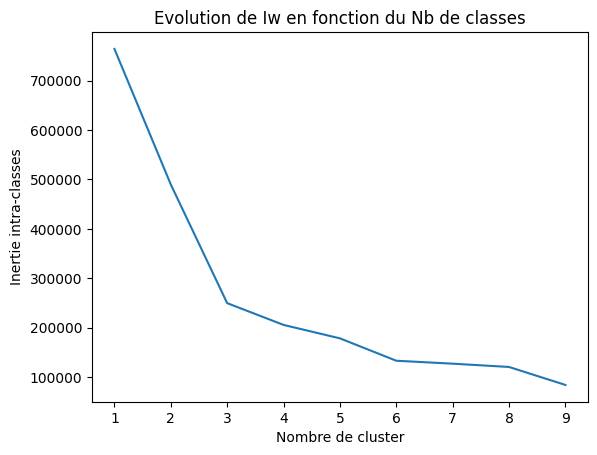

In [ ]:
#Affichage des deux classifications
print(pandas.DataFrame({'Kmeans':kmeans.labels_,'ID':X.index,'FCM':labels}))

# Kmeans et critère intraclasses
a=[]
for i in range(1,10):
    kmeans = cluster.KMeans(n_clusters=i)
    kmeans.fit(X)
    a.append(kmeans.inertia_)
plt.plot(range(1,10),a)
plt.title("Evolution de Iw en fonction du Nb de classes")
plt.xlabel("Nombre de cluster")
plt.ylabel("Inertie intra-classes")
plt.show()